In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import datetime as dt

import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [2]:
import sys

sys.path.append("../src")
sys.path.append("../src/bout")

In [3]:
from core import SITE_NAMES, FREQ_GROUPS
import clustering as clstr
import bout.assembly as bt
import bout.clustering as clstr
import plot as bt_plt
import activity.subsampling as ss
import activity.activity_assembly as actvt
import pipeline

from cli import get_file_paths

In [4]:
site_key = 'Carp'
freq_key = 'HF'

bout_params = dict()
bout_params['site_key'] = site_key
bout_params['freq_key'] = freq_key

fig_details = dict()
fig_details['site_name'] = SITE_NAMES[site_key]
fig_details['freq_group'] = freq_key.split('_')[0].upper()
if freq_key:
    fig_details['freq_group'] = fig_details['freq_group'] + ' '
fig_details['bin_step'] = 10
fig_details['time_end'] = 2000
print(f'Looking at {fig_details["site_name"]}')

Looking at Carp Pond


In [5]:
location_df = pd.read_csv(f'../data/2022_detector_summaries/{bout_params["site_key"]}/bd2__{bout_params["freq_key"]}{bout_params["site_key"]}_2022_kmeans.csv', index_col=0)

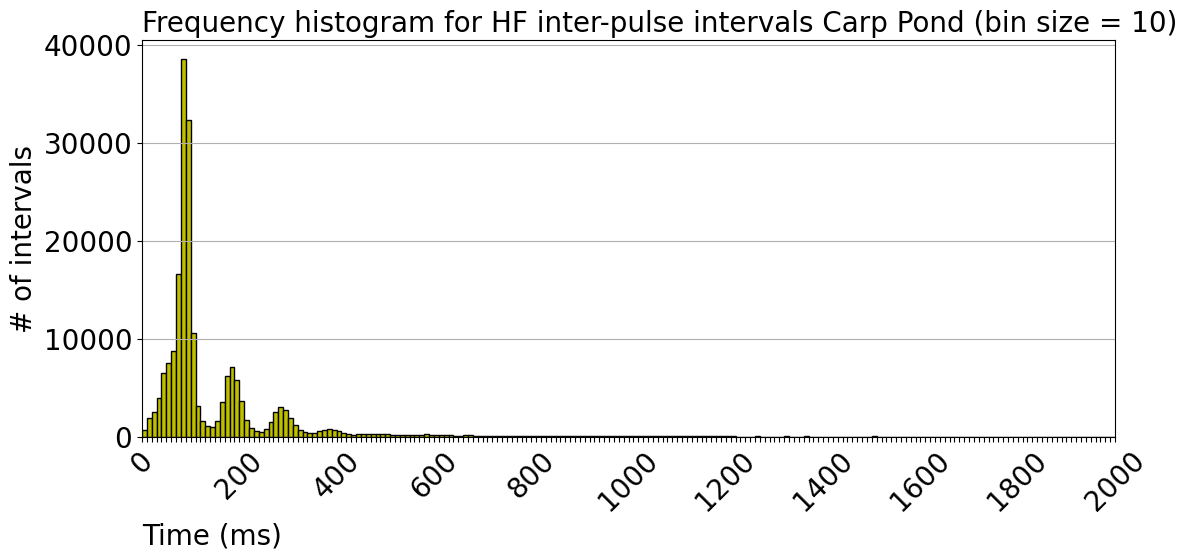

In [6]:
ipis_f, hist_f = bt_plt.plot_ipi_hist(location_df.copy(), fig_details)
plt.rcParams.update({'font.size' : 30})

In [7]:
def plot_nlin_results_over_survival(intervals_ms, survival, fast_process, slow_process, optim_x, optim_bci, bci, fig_details):
    """
    Plots the log-survivorship curve of intervals in the time window to visualize the linear regression of the both processs
    along with two derived BCIs (Slater BCI and Sibly BCI) to see where they are in time.
    """

    fast_start = (intervals_ms[fast_process['indices']][0])
    fast_end = (intervals_ms[fast_process['indices']][-1])
    slow_start = (intervals_ms[slow_process['indices']][0])
    slow_end = (intervals_ms[slow_process['indices']][-1])

    plt.figure(figsize=(12, 6))
    plt.rcParams.update({'font.size' : 20})
    plt.title(f"{fig_details['freq_group']}log-survivorship curve in {fig_details['site_name']}", fontsize=20)
    plt.plot(intervals_ms, survival, marker='.', c='cyan', alpha=0.8)

    plt.plot(intervals_ms, clstr.model(intervals_ms, optim_x[0], optim_x[1], optim_x[2], optim_x[3]), marker='.', c='green', alpha=0.1)
    plt.plot(intervals_ms[fast_process['indices']], survival[fast_process['indices']], marker='.', c='navy')
    plt.plot(intervals_ms[slow_process['indices']], survival[slow_process['indices']], marker='.', c='navy')
    plt.axvline(fast_start, linestyle='dashed', color='k')
    plt.axvline(fast_end, linestyle='dashed', color='k')
    plt.axvline(slow_start, linestyle='dashed', color='k')
    plt.axvline(slow_end, linestyle='dashed', color='k')

    x = np.linspace(-100, intervals_ms[-1], int(slow_end))
    plt.plot(x, fast_process['metrics'].intercept + fast_process['metrics'].slope*x, c='red', alpha=0.6, marker=None, label=f"R^2 = {round(fast_process['metrics'].rvalue**2, 4)}")
    plt.plot(x, slow_process['metrics'].intercept + slow_process['metrics'].slope*x, c='blue', alpha=0.6, marker=None, label=f"R^2 = {round(slow_process['metrics'].rvalue**2, 4)}")

    plt.axvline(bci, linestyle='dashed', linewidth=2, color='yellowgreen', label=f"BCI (Slater et al.): {round(bci/1000, 2)}s")
    plt.axvline(optim_bci, linestyle='dashed', linewidth=2, color='yellowgreen', label=f"BCI (Sibly et al.): {round(optim_bci/1000, 2)}s")
    plt.grid(which='both')
    plt.ylabel('log(# of intervals)', fontsize=18)
    plt.xlabel('Time (ms)', fontsize=18)
    plt.xlim(10e0, 10e6)
    plt.ylim(survival[-1]-0.2, survival[0]+0.2)
    plt.tight_layout()
    plt.legend(loc='upper right', fontsize=14)
    plt.xscale("log")
    plt.show()

In [8]:
def plt_log_survivorship_for_site_group(cur_ax, bout_params):
    fig_details = dict()
    fig_details['site_name'] = SITE_NAMES[bout_params["site_key"]]
    fig_details['freq_group'] = bout_params["freq_key"].split('_')[0].upper()
    if bout_params["freq_key"]:
        fig_details['freq_group'] = fig_details['freq_group'] + ' '
    fig_details['bin_step'] = 10
    print(f'Looking at {fig_details["site_name"]}')

    location_df = pd.read_csv(f'../data/2022_detector_summaries/{bout_params["site_key"]}/bd2__{bout_params["freq_key"]}{bout_params["site_key"]}_2022_kmeans.csv', index_col=0)
    inds_where_dets_above_detection_probability = location_df['det_prob'].astype(float)>=0.35
    location_df_above_detection_probability = location_df[inds_where_dets_above_detection_probability].copy()
    inds_where_dets_above_SNR = location_df_above_detection_probability['SNR'].astype(float)>=3
    location_df_after_thresholds = location_df_above_detection_probability[inds_where_dets_above_SNR].copy()

    ipis_loc, hist_loc = clstr.get_histogram(location_df_after_thresholds, fig_details['bin_step'])
    intervals_ms, survival = clstr.get_log_survival(hist_loc)

    fast_process = clstr.regress_around_fast_intervals(intervals_ms, survival, hist_loc[0])
    fast_process = clstr.calculate_exponential_coefficients(fast_process)

    slow_process = clstr.regress_around_slow_intervals(intervals_ms, survival)
    slow_process = clstr.calculate_exponential_coefficients(slow_process)
    fg_bci, misassigned_points_fg = clstr.get_bci_from_fagenyoung_method(fast_process, slow_process)
    print(f"Fagen&Young method has {round(misassigned_points_fg)} missassigned points")
    bci, misassigned_points = clstr.get_bci_from_slater_method(intervals_ms, survival, fast_process, slow_process)
    print(f"Slater method has {round(misassigned_points)} missassigned points")
    nlin_results, misassigned_points_optim = clstr.get_bci_from_sibly_method(intervals_ms, survival, fast_process, slow_process)
    print(f"Sibly method has {round(misassigned_points_optim)} missassigned points")
    print(f"Optim BCI has less misassignments than BCI? {misassigned_points_optim < misassigned_points}")
    if misassigned_points_optim < misassigned_points:
        print(f"{int(misassigned_points - misassigned_points_optim)} more points assigned correctly")
    fig_details['time_end'] = 60000
    fig_details['site_name'] = SITE_NAMES[bout_params["site_key"]]
    fast_start = (intervals_ms[fast_process['indices']][0])
    fast_end = (intervals_ms[fast_process['indices']][-1])
    slow_start = (intervals_ms[slow_process['indices']][0])
    slow_end = (intervals_ms[slow_process['indices']][-1])

    cur_ax.set_title(f"{fig_details['freq_group']}log-survivorship curve in {fig_details['site_name']}", y=1.05,
            fontsize=plt.rcParams['font.size']+4)
    cur_ax.plot(intervals_ms, survival, marker='.', c='cyan', alpha=0.8)
    cur_ax.plot(intervals_ms[fast_process['indices']], survival[fast_process['indices']], marker='.', c='navy')
    cur_ax.plot(intervals_ms[slow_process['indices']], survival[slow_process['indices']], marker='.', c='navy')
    x = np.linspace(-100, intervals_ms[-1], int(slow_end))
    cur_ax.plot(x, fast_process['metrics'].intercept + fast_process['metrics'].slope*x, c='red', alpha=0.6, marker=None, label=f"$R^2$ = {round(fast_process['metrics'].rvalue**2, 4)}")
    cur_ax.plot(x, slow_process['metrics'].intercept + slow_process['metrics'].slope*x, c='blue', alpha=0.6, marker=None, label=f"$R^2$ = {round(slow_process['metrics'].rvalue**2, 4)}")
    cur_ax.axvline(bci, linestyle='dashed', linewidth=2, color='darkred', label=f"BCI (Slater et al.): {round(bci/1000, 2)}s")
    cur_ax.axvline(nlin_results['bci'], linestyle='dashed', linewidth=2, color='yellowgreen', label=f"BCI (Sibly et al.): {round(nlin_results['bci']/1000, 2)}s")
    cur_ax.axvline(fast_end, linestyle='dashed', color='k')
    cur_ax.axvline(slow_start, linestyle='dashed', color='k')
    cur_ax.set_yticks(np.arange(0, 20, 5))


Looking at Carp Pond
Fagen&Young method has 2189617634 missassigned points
Slater method has 2635785 missassigned points
Sibly method has 5213609 missassigned points
Optim BCI has less misassignments than BCI? False
Looking at Telephone Field
Fagen&Young method has 986532445 missassigned points
Slater method has 2512115 missassigned points
Sibly method has 6371039 missassigned points
Optim BCI has less misassignments than BCI? False
Looking at Carp Pond
Fagen&Young method has 1666778310 missassigned points
Slater method has 2672027 missassigned points
Sibly method has 2736630 missassigned points
Optim BCI has less misassignments than BCI? False
Looking at Telephone Field
Fagen&Young method has 2146727373 missassigned points
Slater method has 2167617 missassigned points
Sibly method has 2276630 missassigned points
Optim BCI has less misassignments than BCI? False


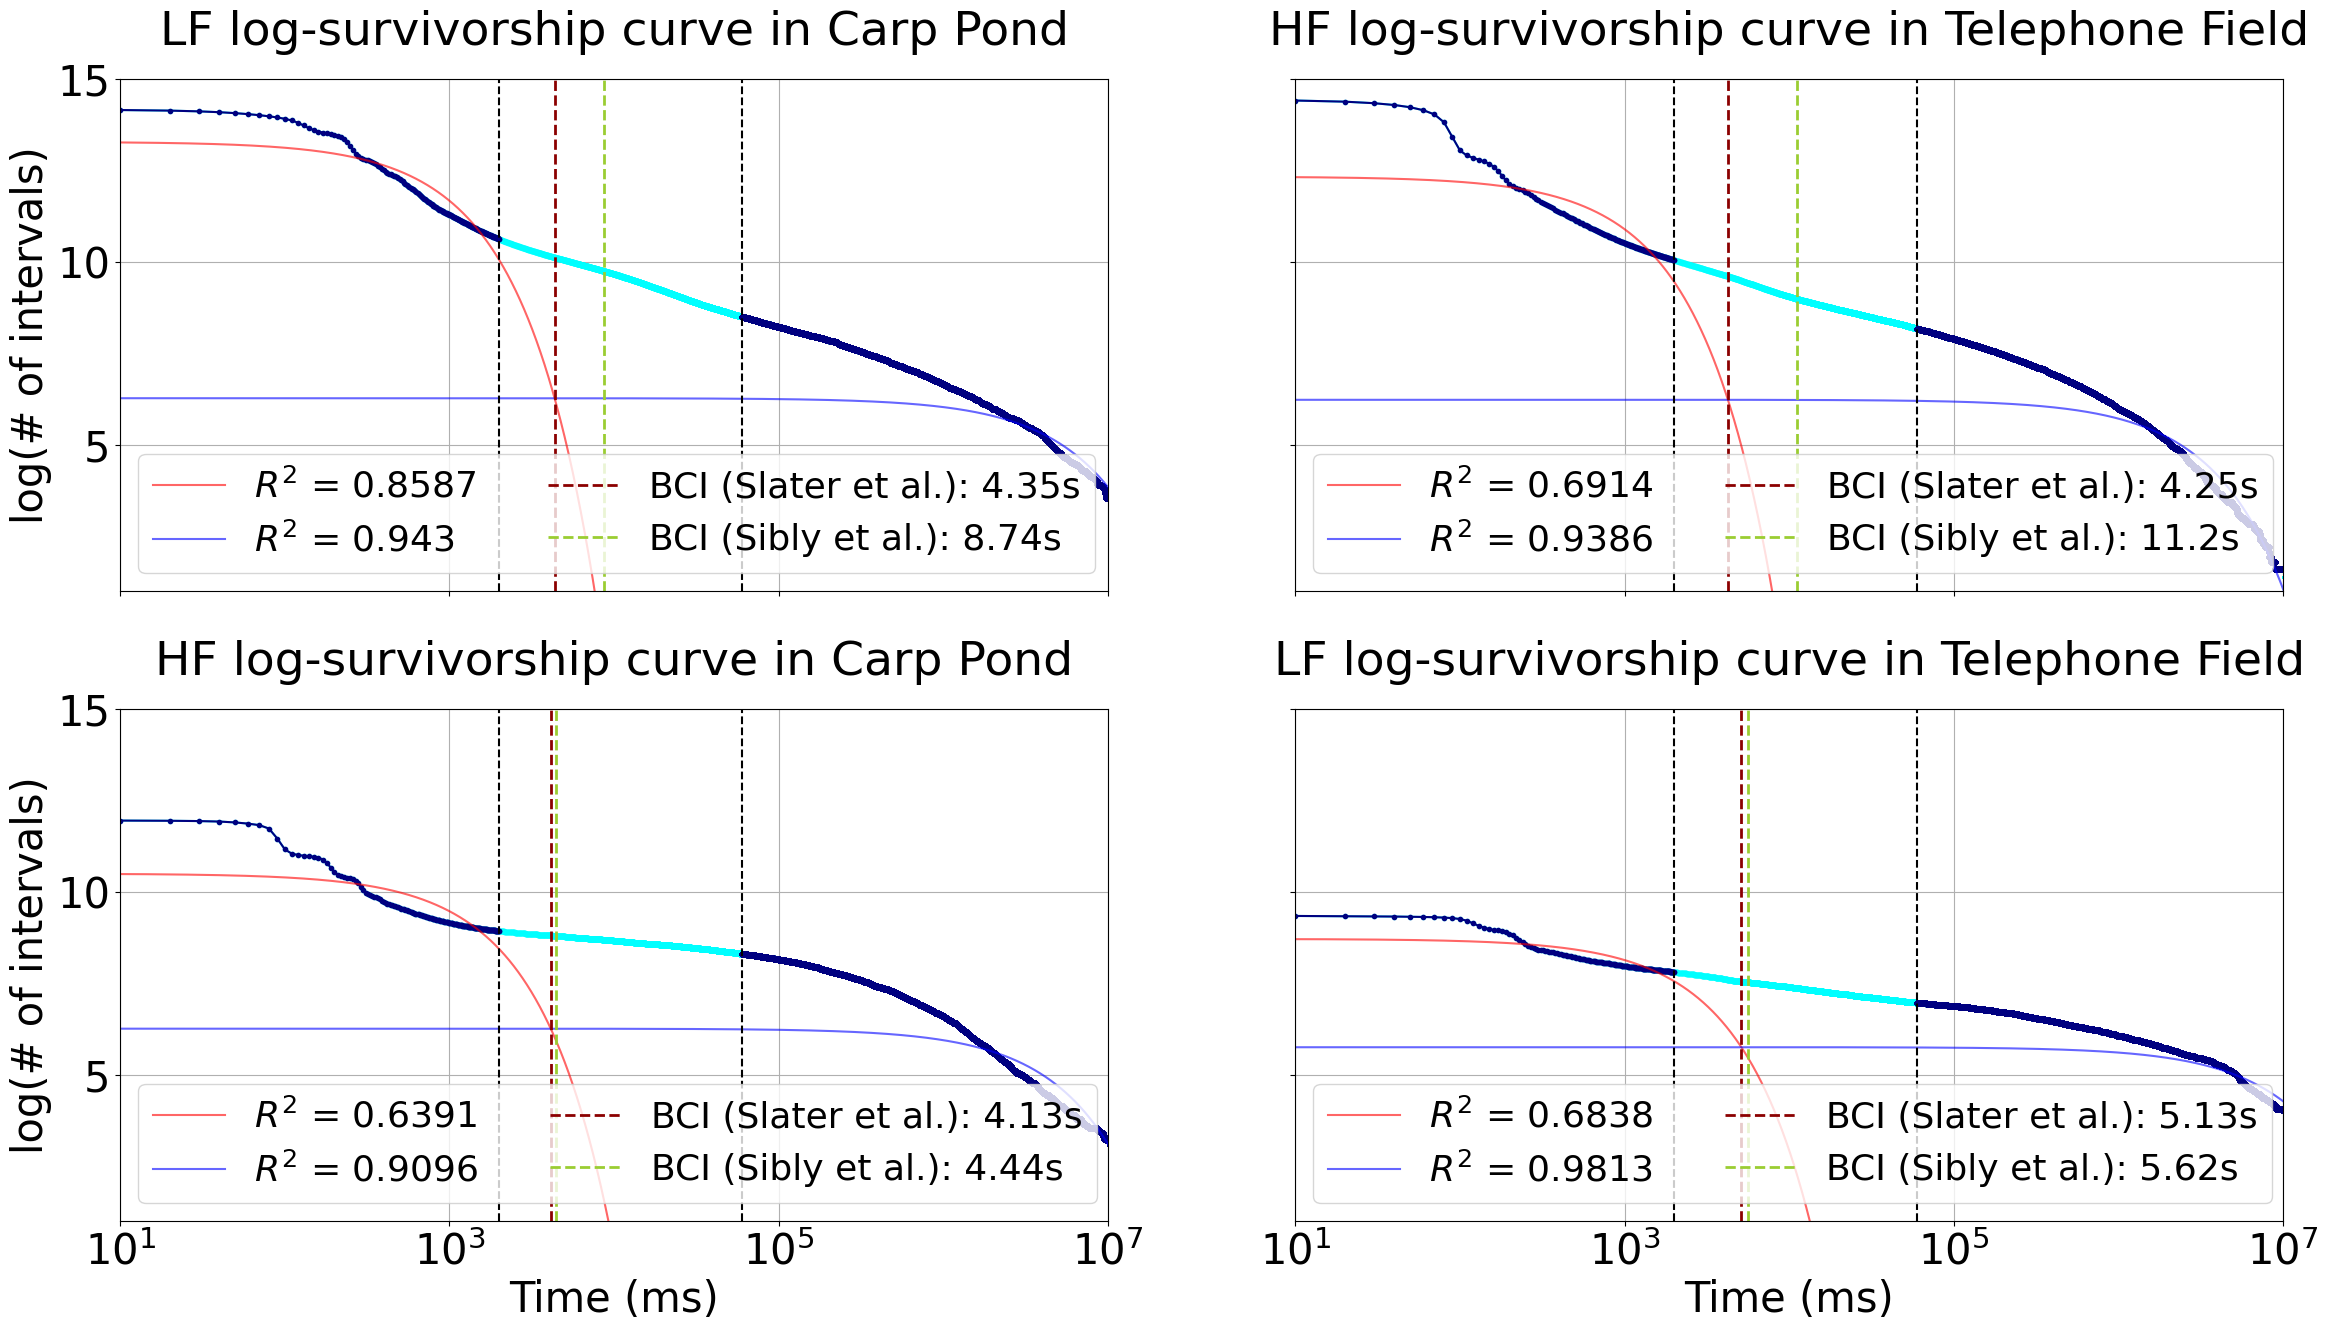

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(24.7, 14), constrained_layout=True, sharey=True, sharex=True)
ax1, ax2, ax3, ax4 = ax[0,0], ax[0,1], ax[1,0], ax[1,1]
plt.rcParams.update({'font.size' : 30})

site_key = 'Carp'
freq_key = 'LF'
bout_params = dict()
bout_params['site_key'] = site_key
bout_params['freq_key'] = freq_key
cur_ax = ax1
plt_log_survivorship_for_site_group(cur_ax, bout_params)
cur_ax.grid(which='both')
cur_ax.set_ylabel('log(# of intervals)', fontsize=plt.rcParams['font.size'])
cur_ax.set_xlim(10e0, 10e6)
cur_ax.legend(loc='lower left', ncol=2, fontsize=plt.rcParams['font.size']-4)
cur_ax.set_xscale("log")
cur_ax.set_ylim(1, 15)


site_key = 'Telephone'
freq_key = 'HF'
bout_params = dict()
bout_params['site_key'] = site_key
bout_params['freq_key'] = freq_key
cur_ax = ax2
plt_log_survivorship_for_site_group(cur_ax, bout_params)
cur_ax.grid(which='both')
cur_ax.set_xlim(10e0, 10e6)
cur_ax.legend(loc='lower left', ncol=2, fontsize=plt.rcParams['font.size']-4)
cur_ax.set_xscale("log")
cur_ax.set_ylim(1, 15)


site_key = 'Carp'
freq_key = 'HF'
bout_params = dict()
bout_params['site_key'] = site_key
bout_params['freq_key'] = freq_key
cur_ax = ax3
plt_log_survivorship_for_site_group(cur_ax, bout_params)
cur_ax.grid(which='both')
cur_ax.set_xlim(10e0, 10e6)
cur_ax.legend(loc='lower left', ncol=2, fontsize=plt.rcParams['font.size']-4)
cur_ax.set_xscale("log")
cur_ax.set_xlabel('Time (ms)', fontsize=plt.rcParams['font.size'])
cur_ax.set_ylabel('log(# of intervals)', fontsize=plt.rcParams['font.size'])
cur_ax.set_ylim(1, 15)


site_key = 'Telephone'
freq_key = 'LF'
bout_params = dict()
bout_params['site_key'] = site_key
bout_params['freq_key'] = freq_key
cur_ax = ax4
plt_log_survivorship_for_site_group(cur_ax, bout_params)
cur_ax.grid(which='both')
cur_ax.set_xlim(10e0, 10e6)
cur_ax.legend(loc='lower left', ncol=2, fontsize=plt.rcParams['font.size']-4)
cur_ax.set_xscale("log")
cur_ax.set_xlabel('Time (ms)', fontsize=plt.rcParams['font.size'])
cur_ax.set_ylim(1, 15)

plt.tight_layout()
plt.show()